# Bid whisperer: one day inside a real-time bidding log

Take-home assignment. The data is a single day (2021-02-01) of US-only real-time
bidding (RTB) ad-request logs: 249,232 impressions and 26 columns. Each row is one
auction opportunity, a chance to show an ad to one user, annotated with who the user
is, where the ad would appear, and what happened in the auction.

The notebook answers the three assignment questions, then keeps going.

1. Characterise the dataset: structure, quality and the RTB funnel.
2. Pick the features most likely to predict a click, and justify the pick with data
   (an analysis, not a model).
3. Propose a way to guess, before bidding, the CPM needed to win a given
   `url × ad_slot` X% of the time.

After that come three sections the brief did not ask for: two machine-learning
models, seven extra analysis layers, and an attempt to undo the obfuscation of the
hashed columns.

### RTB in sixty seconds (sections 2.1, 2.2 and 3.1 of the brief)

When a user loads a page, the publisher auctions each ad slot in real time. Demand
partners (us) receive a bid request and may answer with a bid, a price in CPM (cost
per thousand impressions). The highest bidder wins and shows the ad. In a
first-price auction the winner pays their own bid; in a second-price auction they
pay the runner-up's bid. Our log records whether we `bidded`, our `bid`, whether we
`won_bid`, the `feedback_bid` (the price that decided the auction), and whether the
user `converted` (clicked).

Analysis code lives in `src/` (`data_loading`, `profiling`, `ctr_features`,
`bid_landscape`, `models`, `layers`, `layer_plots`, `decode`, `viz_style`) so it can
be tested and reused. This notebook is the narrative that drives it.


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import data_loading as dl
import profiling as pf
import ctr_features as cf
import bid_landscape as bl
import viz_style as vs

vs.apply_style()
FIG = Path.cwd().parent / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 40, "display.width", 160)

def save(fig, name):
    fig.savefig(FIG / name, dpi=130, bbox_inches="tight")
    return fig
print("Environment ready.")

Environment ready.


In [2]:
df = dl.add_derived(dl.load_raw())
print(f"Loaded {df.shape[0]:,} rows × {df.shape[1]} columns (incl. derived)")
df[["time","user_id","domain","ad_slot","device_type","auction_type",
    "bidded","bid","won_bid","feedback_bid","conversion"]].head(3)

Loaded 249,232 rows × 34 columns (incl. derived)


,time,user_id,domain,ad_slot,device_type,auction_type,bidded,bid,won_bid,feedback_bid,conversion
0,2021-02-01 02:06:25.124621+00:00,11f8b8ea-877a-466e-9a99-d216d5f21c97,8cf5a15cad4d2d30d8e0f61fd8b445b7,5f724d746d2d8d77bb67367f4789057b,PERSONAL_COMPUTER,FIRST_PRICE,0,NaN,NaN,NaN,NaN
1,2021-02-01 17:31:54.038374+00:00,fe106e58-d82a-4090-a519-d27e7029a570,2a2634d779829898f0e0e875ca8a3e8e,c97cf7483babf3a6eba698bd487697dc,PERSONAL_COMPUTER,FIRST_PRICE,1,1.649047,0.0,2.16,0.0
2,2021-02-01 00:09:08.159143+00:00,d0997020-e8d5-4152-88e0-80cc1622bade,728d6192b848c3d7f0addbea66fc1190,acc645d4b2897df49793abac420b173e,HIGHEND_PHONE,FIRST_PRICE,1,1.005495,1.0,0.44,1.0


---
## Q1. Main characteristics of the dataset

We go from structure (schema, types, missingness) to behaviour (the auction funnel,
prices, and where the signal sits).


### 1.1 Schema, types and missingness

In [3]:
overview = pf.schema_overview(df.drop(columns=[c for c in df.columns if c.endswith(('_est','_missing'))] + ["hour","won","clicked","clearing_price"]))
overview

,column,dtype,n_missing,pct_missing,n_unique,example
0,time,"datetime64[us, UTC]",0,0.00,248738,2021-02-01 02:06:25.124621+00:00
1,user_id,str,0,0.00,249232,11f8b8ea-877a-466e-9a99-d216d5f21c97
2,domain,str,10,0.00,8635,8cf5a15cad4d2d30d8e0f61fd8b445b7
3,url,str,0,0.00,44208,6f4424cb37e31fe318d30440cc514a34
4,ad_slot,str,0,0.00,35255,5f724d746d2d8d77bb67367f4789057b
5,country,str,0,0.00,1,US
6,postal_code,string,47258,18.96,33298,37934.0
7,state_code,str,8459,3.39,51,TN
8,city,str,12535,5.03,7994,Knoxville
9,user_agent,str,38,0.02,20657,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:8...


Two facts fall out of the overview, and both change what we do downstream.

Two columns are constant. `country` is always `US` and `screen_orientation` never
changes, so neither carries information and both can be dropped.

Missingness is structural, not random. `bid`, `won_bid`, `feedback_bid` and
`conversion` are missing on exactly the rows where we did not bid (`bidded == 0`).
`device_brand` and `device_model` are missing for desktop traffic, because browsers
on a PC do not report a brand. The distinction matters: structural missingness is a
signal, not noise to impute away.

In [4]:
print("Constant columns (drop):", pf.constant_columns(df))
print()
na_when_not_bidded = df.loc[df.bidded==0, ["bid","won_bid","feedback_bid","conversion"]].isna().all(axis=1).mean()
print(f"Rows with bidded==0 that are fully NaN on auction-outcome cols: {na_when_not_bidded:.1%}")
print("device_brand null rate on desktop:",
      f"{df.loc[df.device_type=='PERSONAL_COMPUTER','device_brand'].isna().mean():.1%}")

Constant columns (drop): ['country', 'screen_orientation']

Rows with bidded==0 that are fully NaN on auction-outcome cols: 100.0%
device_brand null rate on desktop: 100.0%


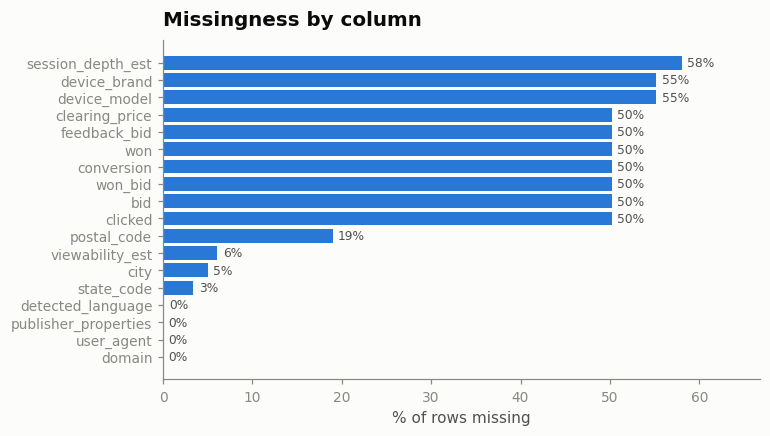

In [5]:
# Missingness bar chart (only columns that actually have gaps)
miss = (df.isna().mean()*100)
miss = miss[miss>0].sort_values()
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(miss.index, miss.values, color=vs.SEQUENTIAL)
for y,v in enumerate(miss.values):
    ax.text(v+0.6, y, f"{v:.0f}%", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Missingness by column", "% of rows missing", None)
ax.set_xlim(0, miss.max()*1.15); ax.grid(False)
save(fig, "q1_missingness.png"); plt.show()

### 1.2 The RTB funnel: where opportunities go

,stage,count,pct_of_requests,pct_of_prev_meaningful
0,Requests (opportunities),"249,232",100.0%,nan%
1,Bidded,"124,152",49.8%,49.8%
2,Won auction,"46,562",18.7%,37.5%
3,Converted (click),"4,368",1.8%,9.4%


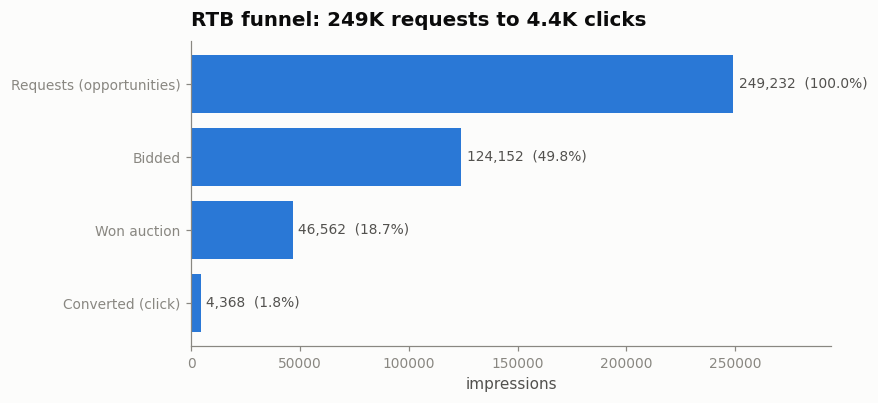

In [6]:
funnel = pf.funnel(df)
display(funnel.style.format({"count":"{:,.0f}","pct_of_requests":"{:.1%}","pct_of_prev_meaningful":"{:.1%}"}))

stages = funnel["stage"].tolist(); counts = funnel["count"].tolist()
fig, ax = plt.subplots(figsize=(7.5,3.6))
bars = ax.barh(range(len(stages)), counts, color=[vs.CATEGORICAL[0]]+[vs.SEQUENTIAL]*3)
ax.set_yticks(range(len(stages))); ax.set_yticklabels(stages); ax.invert_yaxis()
for i,(c,b) in enumerate(zip(counts,bars)):
    pct = c/counts[0]
    ax.text(c+2500, i, f"{c:,}  ({pct:.1%})", va="center", fontsize=9, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "RTB funnel: 249K requests to 4.4K clicks", "impressions", None)
ax.set_xlim(0, counts[0]*1.18); ax.grid(False)
save(fig, "q1_funnel.png"); plt.show()

We bid on 49.8% of opportunities, win 37.5% of those, and see a click on 9.4% of
served (won) impressions. The 9.4% is the true CTR, because clicks can only happen
on ads we showed. Dividing clicks by all bids instead gives 3.5%, and that number is
wrong: every lost bid has `conversion == 0` by construction. CTR is only defined on
the won subset, and Q2 is computed there.

### 1.3 Prices are heavy-tailed, and auction type splits the market in two

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max
bid,124152.0,4.133,20.869,0.06,0.131,0.302,0.74,1.83,4.712,78.662,700.00
feedback_bid,124150.0,4.838,26.679,0.01,0.210,0.500,1.41,3.29,7.120,43.548,1243.75


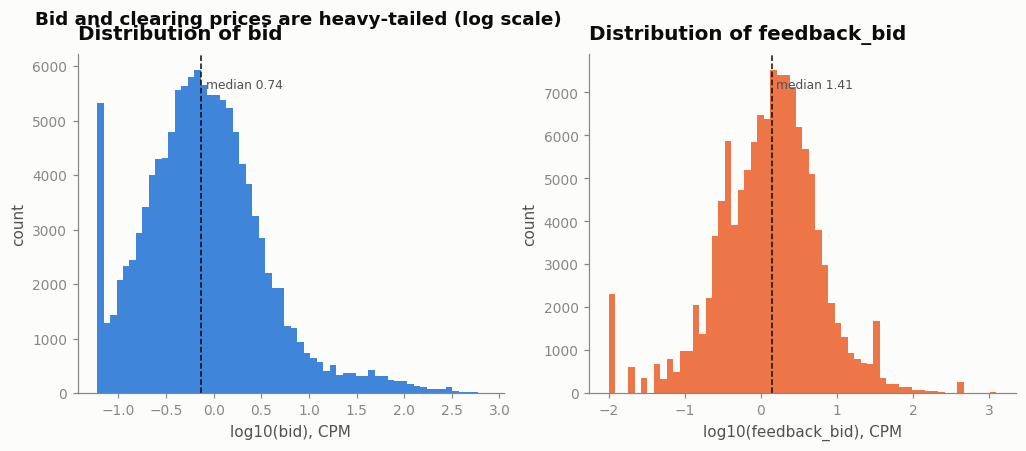

In [7]:
bidded = dl.bidded_frame(df)
display(pf.numeric_summary(bidded, ["bid","feedback_bid"]))

fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax,col,color in zip(axes, ["bid","feedback_bid"], [vs.CATEGORICAL[0], vs.CATEGORICAL[1]]):
    data = bidded[col].dropna()
    data = data[data>0]
    ax.hist(np.log10(data), bins=60, color=color, alpha=0.9)
    ax.set_xlabel(f"log10({col}), CPM"); ax.grid(False)
    med = np.log10(data.median())
    ax.axvline(med, color=vs.INK, lw=1, ls="--")
    ax.text(med+0.05, ax.get_ylim()[1]*0.9, f"median {data.median():.2f}", fontsize=8, color=vs.INK_SECONDARY)
    vs.despine_labels(ax, f"Distribution of {col}", None, "count")
fig.suptitle("Bid and clearing prices are heavy-tailed (log scale)", x=0.09, ha="left", weight="bold")
save(fig, "q1_price_dist.png"); plt.show()

In [8]:
at = bidded.groupby("auction_type").agg(
    n=("won_bid","size"), share=("won_bid", lambda s: len(s)/len(bidded)),
    win_rate=("won_bid","mean"), median_bid=("bid","median"), median_feedback=("feedback_bid","median"))
display(at.style.format({"n":"{:,.0f}","share":"{:.1%}","win_rate":"{:.1%}","median_bid":"{:.2f}","median_feedback":"{:.2f}"}))

,n,share,win_rate,median_bid,median_feedback
auction_type,,,,,
FIRST_PRICE,"114,871",92.5%,33.2%,0.66,1.31
SECOND_PRICE,"9,281",7.5%,90.4%,12.79,8.64


This is the single most important structural fact for bidding. The two auction
types behave like different markets. First-price auctions take 92% of our bids and
are competitive: we win about 33% of them at a median bid near 1.4 CPM.
Second-price auctions are close to a monopoly: we win about 90%, and the clearing
prices are an order of magnitude higher. Any pricing or win-rate logic (Q3) has to
stratify by `auction_type`, or the two regimes blur into a meaningless average.

### 1.4 Who and where: device and geography

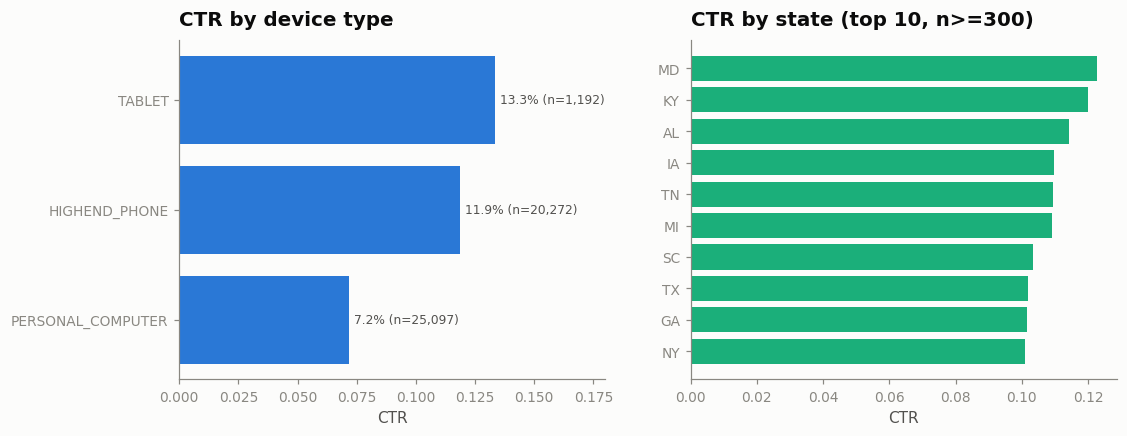

In [9]:
won = dl.won_frame(df)
dev = pf.rate_by_category(won, "device_type", "conversion", min_n=50).rename(columns={"rate":"ctr"})
top_states = pf.rate_by_category(won, "state_code", "conversion", min_n=300).rename(columns={"rate":"ctr"}).head(10)

fig, axes = plt.subplots(1,2, figsize=(11,4))
axes[0].barh(dev["device_type"], dev["ctr"], color=vs.SEQUENTIAL)
axes[0].invert_yaxis()
for y,(v,n) in enumerate(zip(dev["ctr"],dev["n"])):
    axes[0].text(v+0.002, y, f"{v:.1%} (n={n:,})", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(axes[0], "CTR by device type", "CTR", None); axes[0].grid(False); axes[0].set_xlim(0, dev["ctr"].max()*1.35)

axes[1].barh(top_states["state_code"], top_states["ctr"], color=vs.CATEGORICAL[2])
axes[1].invert_yaxis()
vs.despine_labels(axes[1], "CTR by state (top 10, n>=300)", "CTR", None); axes[1].grid(False)
save(fig, "q1_device_geo.png"); plt.show()

What Q1 established. One clean day of 249,232 US impressions, with `country` and
`screen_orientation` constant and droppable. The funnel runs 50% bid, 37.5% win,
9.4% CTR on won impressions, and the missingness is structural (tied to `bidded` and
to desktop device reporting). Prices are heavy-tailed and auction type splits the
market, which is the lever Q3 pulls. Clicks concentrate on phones and tablets and
vary by state, which is where Q2 starts.


---
## Q2. The most promising features for predicting CTR

The brief asks for an analysis: a justified feature set, not a trained model. Two
principles shape the answer.

Guard against leakage. In production we would score CTR before deciding whether and
what to bid, so any field produced by or after the auction is off limits as a
predictor: `bid`, `won_bid`, `feedback_bid`, and `conversion` itself. Including them
would inflate offline metrics and be unusable at bid time.

Condition on the served set. CTR only exists where `won_bid == 1`, so features are
ranked on that subset.

Clicks are rare (about 9%), so raw correlation is a poor screen. For categorical
features we use information value (IV), built from weight of evidence, the standard
screening measure for predictors of a rare binary event in credit scoring. For
numeric features we use mutual information, which picks up non-linear association.
Both are model-agnostic.


In [10]:
print("Excluded as leakage:", sorted(cf.LEAKAGE_COLUMNS))
print("Excluded as raw identifiers (high-cardinality / obfuscated):", sorted(cf.IDENTIFIER_COLUMNS))

cat_candidates = ["device_brand","device_type","detected_language","is_wifi",
                  "auction_type","state_code","city","hour","viewability_missing","session_depth_missing"]
num_candidates = ["viewability_est","session_depth_est","cookie_age_seconds"]
print("\nCategorical candidates:", cat_candidates)
print("Numeric candidates:", num_candidates)

Excluded as leakage: ['bid', 'clearing_price', 'clicked', 'conversion', 'feedback_bid', 'won', 'won_bid']
Excluded as raw identifiers (high-cardinality / obfuscated): ['ad_slot', 'domain', 'publisher_properties', 'time', 'url', 'user_agent', 'user_id']

Categorical candidates: ['device_brand', 'device_type', 'detected_language', 'is_wifi', 'auction_type', 'state_code', 'city', 'hour', 'viewability_missing', 'session_depth_missing']
Numeric candidates: ['viewability_est', 'session_depth_est', 'cookie_age_seconds']


### 2.1 Categorical feature strength: information value

,feature,information_value,n_unique,strength
0,device_brand,0.1059,53,medium
1,device_type,0.0797,4,weak
2,viewability_missing,0.0464,2,weak
3,city,0.0326,5195,weak
4,state_code,0.0260,51,weak
5,auction_type,0.0223,2,weak
6,is_wifi,0.0166,2,useless
7,hour,0.0143,24,useless
8,detected_language,0.0036,18,useless
9,session_depth_missing,0.0005,2,useless


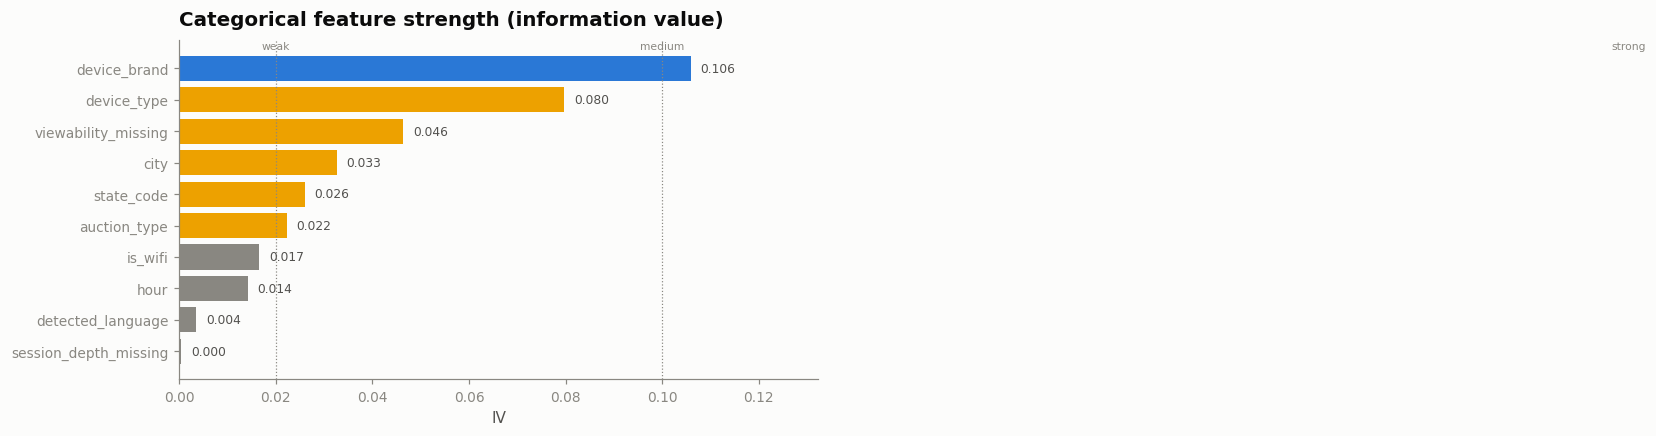

In [11]:
iv = cf.rank_categorical_iv(won, cat_candidates)
display(iv.style.format({"information_value":"{:.4f}"}))

fig, ax = plt.subplots(figsize=(7.5,4))
colors = {"strong":vs.STATUS["good"], "medium":vs.CATEGORICAL[0], "weak":vs.CATEGORICAL[3], "useless":vs.INK_MUTED}
bar_colors = [colors[str(s)] for s in iv["strength"]]
ax.barh(iv["feature"], iv["information_value"], color=bar_colors)
ax.invert_yaxis()
for th,lab in [(0.02,"weak"),(0.1,"medium"),(0.3,"strong")]:
    ax.axvline(th, color=vs.INK_MUTED, lw=0.8, ls=":")
    ax.text(th, -0.6, lab, fontsize=7, color=vs.INK_MUTED, ha="center")
for y,v in enumerate(iv["information_value"]):
    ax.text(v+0.002, y, f"{v:.3f}", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Categorical feature strength (information value)", "IV", None)
ax.grid(False); ax.set_xlim(0, iv["information_value"].max()*1.25)
save(fig, "q2_iv_ranking.png"); plt.show()

### 2.2 Numeric feature strength: mutual information

,feature,mutual_info
0,session_depth_est,0.01785
1,viewability_est,0.01102
2,cookie_age_seconds,0.00315


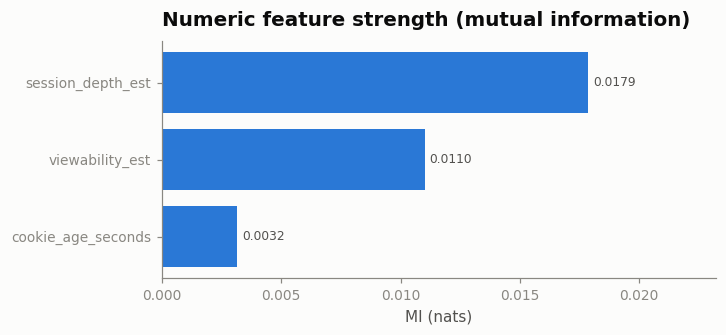

In [12]:
mi = cf.rank_numeric_mi(won, num_candidates)
display(mi.style.format({"mutual_info":"{:.5f}"}))

fig, ax = plt.subplots(figsize=(6.5,2.8))
ax.barh(mi["feature"], mi["mutual_info"], color=vs.SEQUENTIAL); ax.invert_yaxis()
for y,v in enumerate(mi["mutual_info"]):
    ax.text(v+2e-4, y, f"{v:.4f}", va="center", fontsize=8, color=vs.INK_SECONDARY)
vs.despine_labels(ax, "Numeric feature strength (mutual information)", "MI (nats)", None)
ax.grid(False); ax.set_xlim(0, mi["mutual_info"].max()*1.3)
save(fig, "q2_mi_ranking.png"); plt.show()

### 2.3 What the top features look like

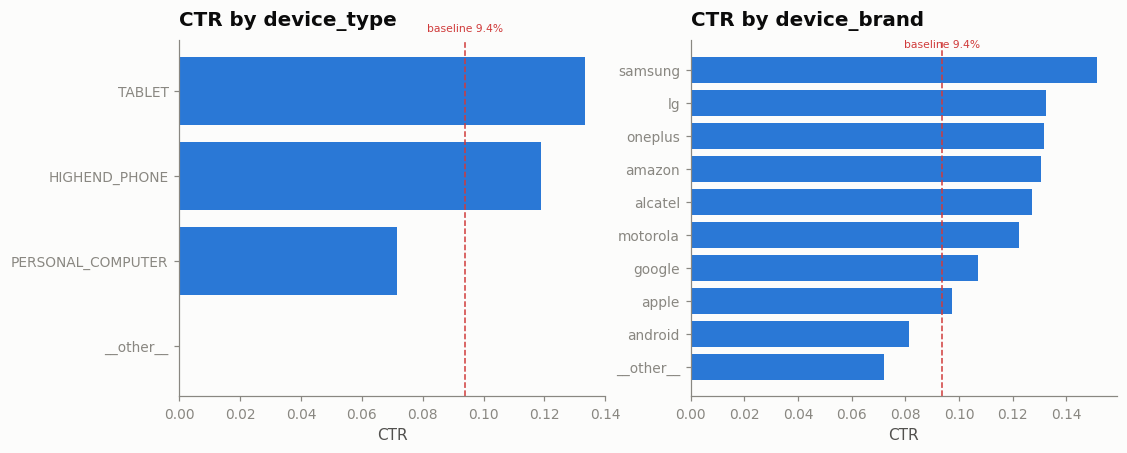

In [13]:
# WoE detail: CTR across the levels of the two strongest categoricals.
fig, axes = plt.subplots(1,2, figsize=(11,4.2))
for ax, feat, k in zip(axes, ["device_type","device_brand"], [4, 12]):
    tab,_ = cf.woe_iv(won, feat)
    tab = tab.sort_values("ctr", ascending=False).head(k)
    ax.barh(tab.index.astype(str), tab["ctr"], color=vs.SEQUENTIAL); ax.invert_yaxis()
    ax.axvline(won["conversion"].mean(), color=vs.STATUS["critical"], lw=1, ls="--")
    ax.text(won["conversion"].mean(), -0.7, f"baseline {won['conversion'].mean():.1%}",
            fontsize=7, color=vs.STATUS["critical"], ha="center")
    vs.despine_labels(ax, f"CTR by {feat}", "CTR", None); ax.grid(False)
save(fig, "q2_woe_detail.png"); plt.show()

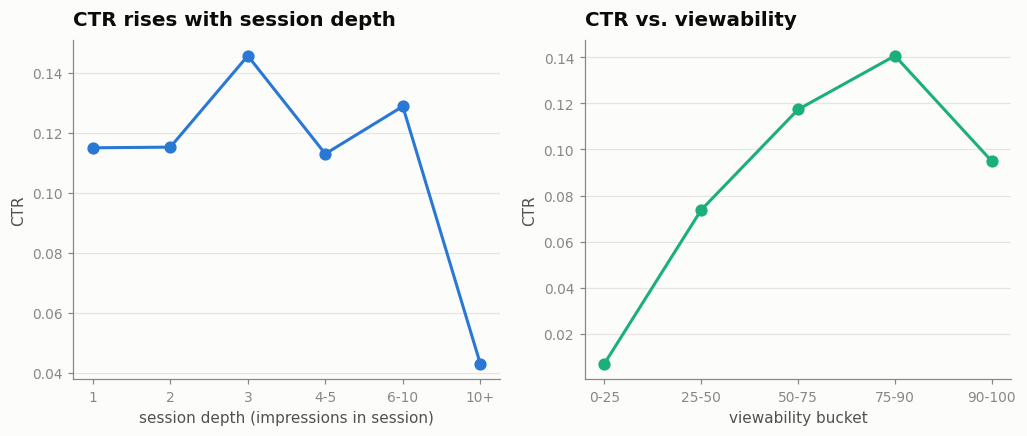

In [14]:
# Sessions and viewability: does engagement/quality move CTR?
fig, axes = plt.subplots(1,2, figsize=(11,4))
# session depth bucketed
w = won.copy()
w["sd_bin"] = pd.cut(w["session_depth_est"], [0,1,2,3,5,10,1e9],
                     labels=["1","2","3","4-5","6-10","10+"])
sd = w.groupby("sd_bin")["conversion"].agg(["mean","size"]).dropna()
axes[0].plot(sd.index.astype(str), sd["mean"], marker="o", color=vs.CATEGORICAL[0], lw=2, ms=7)
vs.despine_labels(axes[0], "CTR rises with session depth", "session depth (impressions in session)", "CTR")
# viewability bucketed
w["vb_bin"] = pd.cut(w["viewability_est"], [-1,25,50,75,90,100], labels=["0-25","25-50","50-75","75-90","90-100"])
vb = w.groupby("vb_bin")["conversion"].agg(["mean","size"]).dropna()
axes[1].plot(vb.index.astype(str), vb["mean"], marker="o", color=vs.CATEGORICAL[2], lw=2, ms=7)
vs.despine_labels(axes[1], "CTR vs. viewability", "viewability bucket", "CTR")
save(fig, "q2_signal_trends.png"); plt.show()

### 2.4 Recommended feature set, with the justification

Ranked by measured association on the served set, with leakage excluded:

| Feature | Type | Signal | Why it makes the cut |
|---|---|---|---|
| `device_brand` | categorical | IV about 0.11 (medium) | Strongest single predictor; brand stands in for platform, price tier and how the ad renders. |
| `device_type` | categorical | IV about 0.08 | Phones and tablets click far more than desktops; low cardinality and stable. |
| `session_depth` | numeric | highest MI | Deeper sessions click more, and the relation is monotone. Keep the `-1` missing flag. |
| `viewability` | numeric | second MI | The odds the ad is seen at all. Keep the `-1` missing flag. |
| `state_code` | categorical | IV about 0.03 | Weak but cheap and stable; useful as a target-encoded aggregate. |
| `auction_type` | categorical | IV about 0.02 | Weak for CTR but needed as context, and free. |
| `cookie_age_seconds` | numeric | low MI | A recency and identity proxy; better bucketed (new vs established cookie). |

Deliberately excluded: the leakage columns (`bid`, `won_bid`, `feedback_bid`), the
constants (`country`, `screen_orientation`), the near-constant and noisy fields
(`detected_language` is 98% `en`; `is_wifi` and raw `hour` add little), and the raw
identifiers (`user_id`, `url`, `domain`, `ad_slot`, `user_agent`). The identifiers
are not usable as raw categories with tens of thousands of levels, but a smoothed
historical CTR per `ad_slot`, `url` or `domain` is typically the single strongest
input in a production CTR model, and it is the natural next step. The
machine-learning section later in this notebook measures exactly that.

The short version: device identity, engagement and quality (session depth,
viewability) and light geographic context form the promising, leakage-safe core.
The biggest future lift comes from historical CTR aggregates over the identifier
columns.


---
## Q3. Guessing the pre-bid CPM that wins X% of the time, per `url × ad_slot`

Restated: build `bid(url, ad_slot, X)`, the CPM that wins the auction X% of the
time, computable before we bid.

To win, our bid has to exceed the market's clearing price for that slot. If `F` is
the CDF of the clearing price, then

$$P(\text{win} \mid \text{bid}=b) = P(b > \text{clearing price}) = F(b),$$

so the bid that wins a fraction \(X\) of the time is the X-th quantile of the
clearing-price distribution for that `url × ad_slot`:

$$\text{bid}(X) = F^{-1}(X) = Q_X(\text{clearing price}).$$

Q3 therefore reduces to estimating clearing-price quantiles per slot.

Where does the clearing price come from? From `feedback_bid`, which is the price
that decided the auction under both auction types: the winner's bid when we lost,
the runner-up's bid when we won a first-price auction. It is our best single-number
read of what it took to win that slot, so `clearing_price` is set to `feedback_bid`
in `src/data_loading.add_derived`.


### 3.1 The real obstacle: sparsity

Unique (url, ad_slot) pairs: 13,817
Median observations per pair: 2
  pairs with >=  1 obs: 13,817  (100.0%)
  pairs with >=  5 obs:  4,047  (29.3%)
  pairs with >= 20 obs:  1,075  (7.8%)
  pairs with >= 50 obs:    359  (2.6%)
  pairs with >=100 obs:    168  (1.2%)


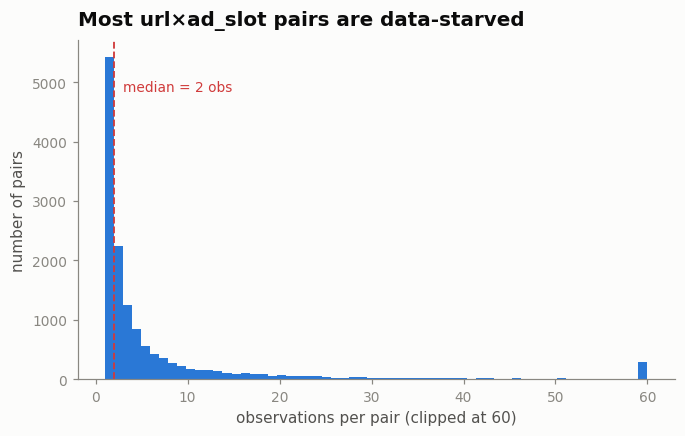

In [15]:
pair_n = bidded.dropna(subset=["clearing_price"]).groupby(["url","ad_slot"]).size()
print(f"Unique (url, ad_slot) pairs: {pair_n.size:,}")
print(f"Median observations per pair: {pair_n.median():.0f}")
for th in [1,5,20,50,100]:
    print(f"  pairs with >={th:>3} obs: {(pair_n>=th).sum():>6,}  ({(pair_n>=th).mean():.1%})")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(np.clip(pair_n.values,0,60), bins=60, color=vs.SEQUENTIAL)
ax.axvline(pair_n.median(), color=vs.STATUS["critical"], lw=1.2, ls="--")
ax.text(pair_n.median()+1, ax.get_ylim()[1]*0.85, f"median = {pair_n.median():.0f} obs",
        color=vs.STATUS["critical"], fontsize=9)
vs.despine_labels(ax, "Most url×ad_slot pairs are data-starved", "observations per pair (clipped at 60)", "number of pairs")
ax.grid(False); save(fig, "q3_sparsity.png"); plt.show()

A raw per-pair empirical quantile is hopeless when the median pair has two
observations. The fix is hierarchical partial pooling, also called empirical-Bayes
shrinkage: estimate the quantile at the pair level where the data is rich, and
otherwise borrow strength from progressively broader levels (`url`, then `ad_slot`,
then `domain`, then the auction-type stratum, then global), weighting each level by
its support. Pooling never crosses the `auction_type` boundary, because section 1.3
showed those are different price regimes. `src/bid_landscape.HierarchicalQuantileModel`
implements this.

### 3.2 Fit the model and read off bid curves

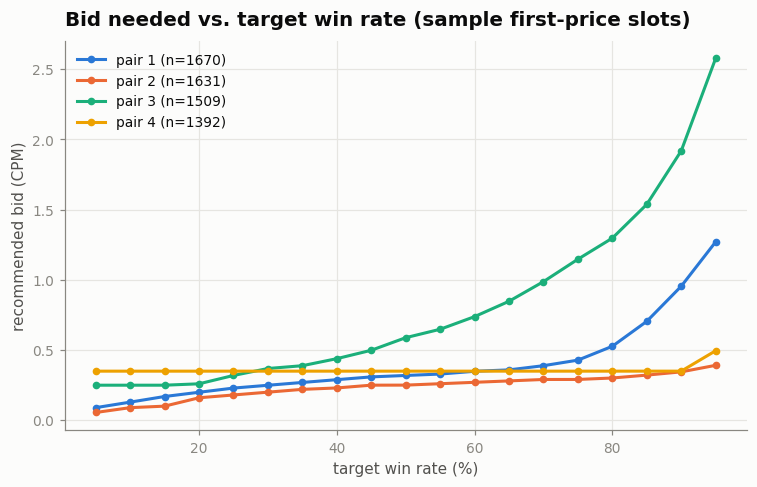

In [16]:
model = bl.HierarchicalQuantileModel(levels=["url","ad_slot","domain"], pseudo_count=30).fit(bidded)

# Bid curves for a few well-populated first-price pairs.
fp = bidded[(bidded.auction_type=="FIRST_PRICE") & bidded.clearing_price.notna()]
top_pairs = fp.groupby(["url","ad_slot"]).size().sort_values(ascending=False).head(4).index
targets = np.linspace(0.05, 0.95, 19)

fig, ax = plt.subplots(figsize=(8,4.6))
for i,(u,s) in enumerate(top_pairs):
    row = fp[(fp.url==u)&(fp.ad_slot==s)].iloc[0]
    curve = [model.bid_for_winrate(row, x) for x in targets]
    ax.plot(targets*100, curve, marker="o", ms=4, lw=2, color=vs.CATEGORICAL[i],
            label=f"pair {i+1} (n={((fp.url==u)&(fp.ad_slot==s)).sum()})")
vs.despine_labels(ax, "Bid needed vs. target win rate (sample first-price slots)",
                  "target win rate (%)", "recommended bid (CPM)")
ax.legend(); ax.grid(True); save(fig, "q3_bid_curves.png"); plt.show()

Each curve is a slot's supply curve for winning: a higher win rate costs a higher
CPM, and the steepness says how contested the slot is. The curve is directly usable.
Pick a target win rate, read off the bid.

### 3.3 Does it work? A calibration back-test

,target,median_realised,mean_realised,n_pairs
0,20%,20.0%,22.1%,359
1,50%,50.5%,51.5%,359
2,80%,80.1%,80.8%,359


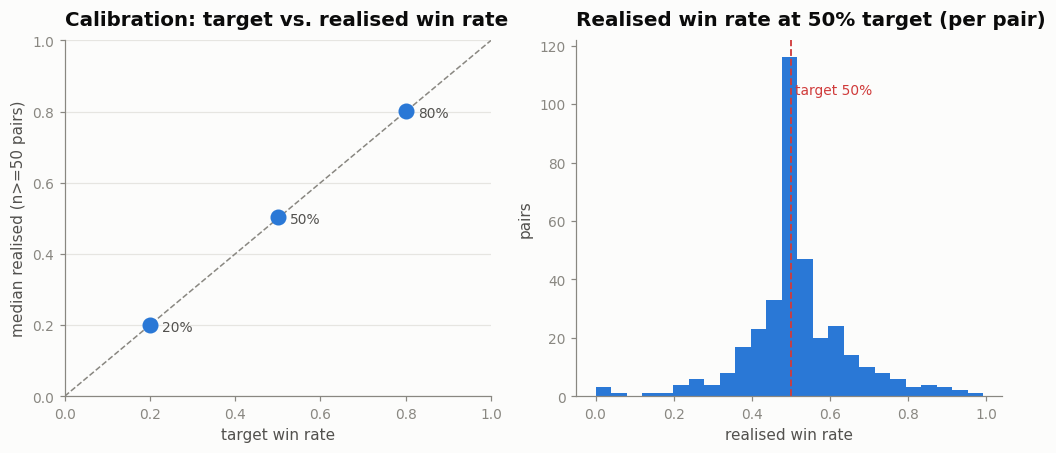

In [17]:
# For well-populated pairs, bid the model's price and measure the realised win rate.
rows = []
for x in [0.2, 0.5, 0.8]:
    cal = bl.calibration_by_pair(bidded, model, x, min_n=50)
    rows.append((x, cal["realised_win_rate"].median(), cal["realised_win_rate"].mean(), len(cal)))
caldf = pd.DataFrame(rows, columns=["target","median_realised","mean_realised","n_pairs"])
display(caldf.style.format({"target":"{:.0%}","median_realised":"{:.1%}","mean_realised":"{:.1%}"}))

cal50 = bl.calibration_by_pair(bidded, model, 0.5, min_n=50)
fig, axes = plt.subplots(1,2, figsize=(11,4.2))
# (a) target vs realised
axes[0].plot([0,1],[0,1], color=vs.INK_MUTED, ls="--", lw=1)
axes[0].scatter(caldf["target"], caldf["median_realised"], s=90, color=vs.CATEGORICAL[0], zorder=3)
for _,r in caldf.iterrows():
    axes[0].annotate(f"{r.median_realised:.0%}", (r.target, r.median_realised),
                     textcoords="offset points", xytext=(8,-4), fontsize=9, color=vs.INK_SECONDARY)
axes[0].set_xlim(0,1); axes[0].set_ylim(0,1)
vs.despine_labels(axes[0], "Calibration: target vs. realised win rate", "target win rate", "median realised (n>=50 pairs)")
# (b) distribution of realised win rates at 50% target
axes[1].hist(cal50["realised_win_rate"], bins=25, color=vs.SEQUENTIAL)
axes[1].axvline(0.5, color=vs.STATUS["critical"], lw=1.2, ls="--")
axes[1].text(0.5+0.01, axes[1].get_ylim()[1]*0.85, "target 50%", color=vs.STATUS["critical"], fontsize=9)
vs.despine_labels(axes[1], "Realised win rate at 50% target (per pair)", "realised win rate", "pairs")
axes[1].grid(False); save(fig, "q3_calibration.png"); plt.show()

The model is calibrated. Across well-populated pairs, bidding the predicted price
for a 50% target wins almost exactly 50% of the time, and the 20% and 80% targets
land on their marks too. Shrinkage keeps sparse pairs sane while letting rich pairs
speak for themselves.

### 3.4 How to run it in production, and where it needs care

The estimator above is the answer, and it can be deployed as is. Precompute, per
auction stratum and per level (`url`, `ad_slot`, `domain`), a small grid of
clearing-price quantiles. At request time, look up the finest level with data and
blend by support. Serving is O(1), there is no online training, and cold slots
degrade gracefully to broader priors.

Three places need care.

Censoring. When we lose, `feedback_bid` is the winner's bid, which is a fair market
read. When we win a first-price auction it is the runner-up, which is a lower bound
on what a rival would have paid. A fully rigorous treatment models the win indicator
against our bid with survival analysis (Kaplan-Meier or Cox) to handle the censoring
explicitly.

Slots with no history. To generalise to unseen slots, replace the ID hierarchy with a
quantile-regression model (gradient-boosted trees with a pinball loss) that uses
`hour`, `device_type`, `viewability` and an encoded domain as inputs. That trades the
interpretability of the hierarchy for coverage on cold-start slots; the
machine-learning section below builds it and compares the two.

Recency. Clearing prices drift. In production, weight recent observations more
(exponential decay) and refresh the quantile grid on a schedule.


---
## Beyond the brief: machine-learning models

The assignment asked for a feature analysis, not a model. Two models are still
worth fitting, for different reasons.

The first is a click-through-rate classifier. It checks whether the Q2 feature
ranking holds up when a model has to use those features together, and it puts a
number on the one thing the Q2 analysis could only gesture at: how much the hashed
identifiers (domain, url, ad slot, publisher properties) add once they are turned
into out-of-fold "historical CTR" encodings.

The second is quantile regression of the clearing price, trained and tested on
disjoint sets of url and ad-slot pairs. That is the cold-start case the Q3 lookup
model handles poorly: a slot it has never seen, where it can only fall back to the
domain or the global distribution.

Ground rules carry over from Q2. Models train on served impressions only, and no
auction outcome (bid, won_bid, feedback_bid) is a feature. All identifier encodings
are out-of-fold, so no row is scored with an encoding that saw its own label.
Code lives in `src/models.py`.

### A CTR classifier, with and without the identifiers


In [18]:
import models as ml

ctr = ml.run_ctr_experiment(won)   # 5-fold stratified CV, fixed seed; about 15 s
display(ctr["metrics"].style.format("{:.4f}"))
print(f"Base click rate: {ctr['base_rate']:.2%} over {ctr['n_rows']:,} served impressions")
print(f"Lift from the identifier encodings: AUC {ctr['id_lift_auc']:+.3f}, average precision {ctr['id_lift_ap']:+.3f}")

,roc_auc,average_precision,log_loss,brier
model,,,,
hgb_full,0.7796,0.2571,0.2655,0.0772
hgb_no_id,0.6866,0.1671,0.2894,0.0821
logreg,0.6755,0.1576,0.2927,0.0824


Base click rate: 9.38% over 46,562 served impressions
Lift from the identifier encodings: AUC +0.093, average precision +0.090


Three models share the same folds. Gradient boosting on the context features
(device, state, hour, viewability, session depth, cookie age, wifi, auction type,
browser and OS parsed from the user agent) reaches an AUC of about 0.69. Logistic
regression on one-hot versions of the same inputs gets 0.68, so the booster is not
finding much non-linearity in the context alone. Adding the four out-of-fold
identifier encodings moves the booster to an AUC of 0.78 and raises average
precision from 0.17 to 0.26 against a base rate of 9.4%. The log loss drops from
0.289 to 0.266.

For a bidder that is the practical result of the whole Q2 exercise: the context
features are real but modest, and most of the predictable variation in clicks sits
in which page and which slot the ad runs on. The hashed IDs are not usable as raw
categories with tens of thousands of levels, but a smoothed historical click rate
per slot is cheap to maintain and is the single most valuable input.


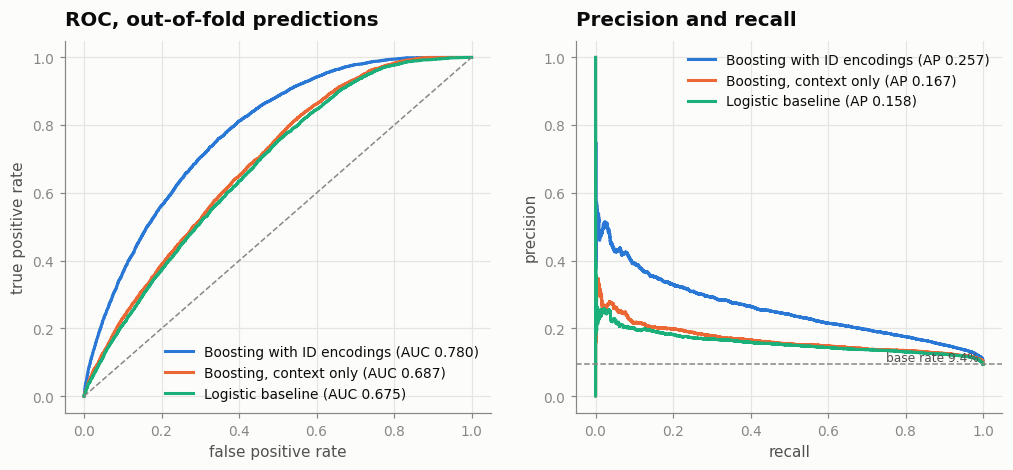

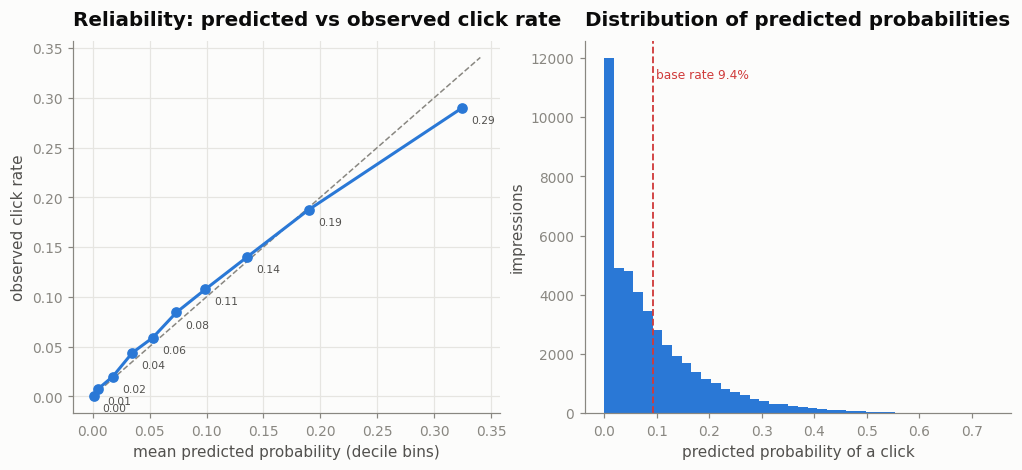

In [19]:
fig = ml.plot_ctr_roc_pr(ctr); save(fig, "ml_ctr_roc_pr.png"); plt.show()
fig = ml.plot_ctr_calibration(ctr); save(fig, "ml_ctr_calibration.png"); plt.show()

The reliability curve is the plot that matters for bidding. A CTR model is
used to price impressions (expected value = predicted CTR times value per click),
so a model that ranks well but is mis-calibrated still misprices. The decile bins
sit close to the diagonal across the range, and the predicted probabilities spread
from under 2% to over 30%, so the model separates cheap and expensive impressions
rather than hovering around the base rate.


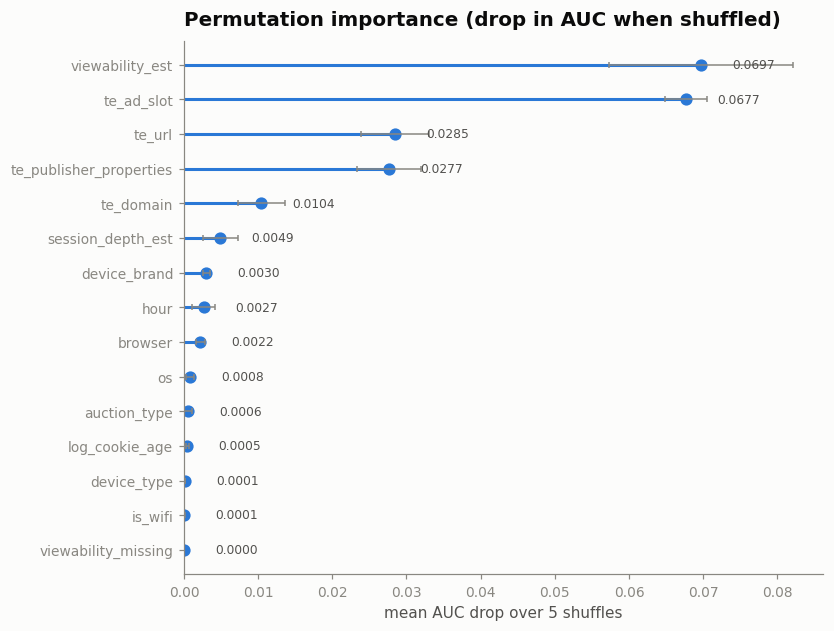

,feature,importance_mean,importance_std
0,viewability_est,0.0697,0.0124
1,te_ad_slot,0.0677,0.0029
2,te_url,0.0285,0.0046
3,te_publisher_properties,0.0277,0.0044
4,te_domain,0.0104,0.0032
5,session_depth_est,0.0049,0.0023
6,device_brand,0.0030,0.0005
7,hour,0.0027,0.0015
8,browser,0.0022,0.0007
9,os,0.0008,0.0006


In [20]:
fig = ml.plot_ctr_importance(ctr, top=15); save(fig, "ml_ctr_importance.png"); plt.show()
display(ctr["importance"].head(10).style.format({"importance_mean": "{:.4f}", "importance_std": "{:.4f}"}))

Permutation importance (the drop in AUC when one column is shuffled on a
held-out fold) tells a slightly different story from the Q2 ranking, and the
difference is informative. Viewability comes first, at roughly 0.07 AUC, followed by
the ad-slot and url encodings and the publisher-properties encoding. Session depth
is next among the context features. Device brand, the top feature by information
value in Q2, drops well down the list.

That is not a contradiction. Device brand, device type and OS carry nearly the same
information (an Apple brand implies iOS implies a phone or tablet), and permutation
importance splits the credit across redundant columns, so each looks small on its
own. The Q2 ranking measured each feature alone; the model measures what each adds
given the others. Read together: keep one device signal, keep viewability and
session depth, and invest in the per-slot historical click rate.


### Pricing slots we have never seen

The Q3 lookup model needs history for a slot. When the pair is new it falls back to
the domain, then to the auction-type global distribution. The question here is
whether a regression model that uses the request context can do better for new
pairs.

The test set is built by holding out 20% of url and ad-slot pairs, so every test
row is a pair the models never trained on. Only about 64% of test rows have a url
that appears anywhere in training, 59% an ad slot, and 87% a domain. Both models are
fitted on the same training rows. The regressor is gradient boosting with a pinball
loss on log clearing price at the 20th, 50th and 80th percentiles, with
auction-type-stratified encodings of domain, url and ad slot as extra inputs.


In [21]:
qr = ml.run_quantile_experiment(bidded)   # grouped 80/20 split by (url, ad_slot); about 20 s
display(qr["table"].style.format({"quantile": "{:.1f}", "coverage": "{:.3f}", "pinball_cpm": "{:.3f}",
                                  "pinball_log": "{:.3f}", "median_bid_cpm": "{:.2f}", "coverage_gap": "{:+.3f}"}))
display(qr["by_auction_type"].style.format({"coverage_at_50": "{:.3f}"}))
print(f"Train pairs {qr['n_train_pairs']:,} | test pairs {qr['n_test_pairs']:,} | test rows {qr['n_test_rows']:,}")
print("Share of test rows whose key appears in training:", {k: round(v, 3) for k, v in qr['test_key_seen_in_train'].items()})

,model,quantile,coverage,pinball_cpm,pinball_log,median_bid_cpm,coverage_gap
0,quantile_regression,0.2,0.278,0.961,0.139,0.81,+0.078
1,hierarchical_lookup,0.2,0.255,0.968,0.147,0.53,+0.055
2,quantile_regression,0.5,0.541,2.014,0.219,1.61,+0.041
3,hierarchical_lookup,0.5,0.522,2.122,0.249,1.31,+0.022
4,quantile_regression,0.8,0.804,2.468,0.177,3.15,+0.004
5,hierarchical_lookup,0.8,0.798,2.495,0.198,3.25,-0.002


,model,auction_type,n,coverage_at_50
0,quantile_regression,FIRST_PRICE,21931,0.546
1,quantile_regression,SECOND_PRICE,2042,0.486
2,hierarchical_lookup,FIRST_PRICE,21931,0.520
3,hierarchical_lookup,SECOND_PRICE,2042,0.536


Train pairs 11,053 | test pairs 2,764 | test rows 23,973
Share of test rows whose key appears in training: {'url': 0.64, 'ad_slot': 0.593, 'domain': 0.867}


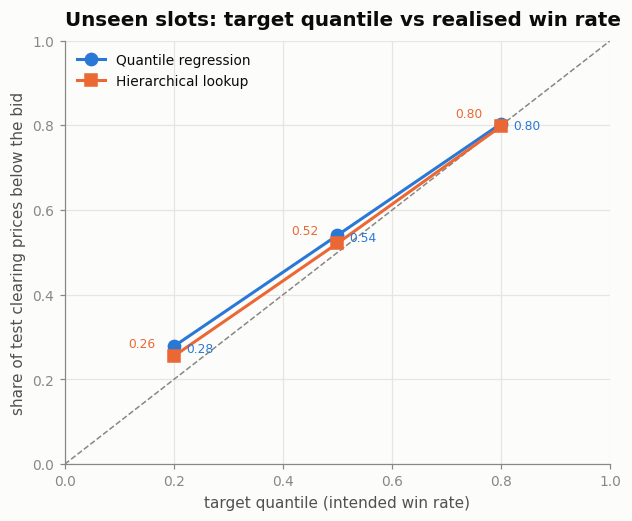

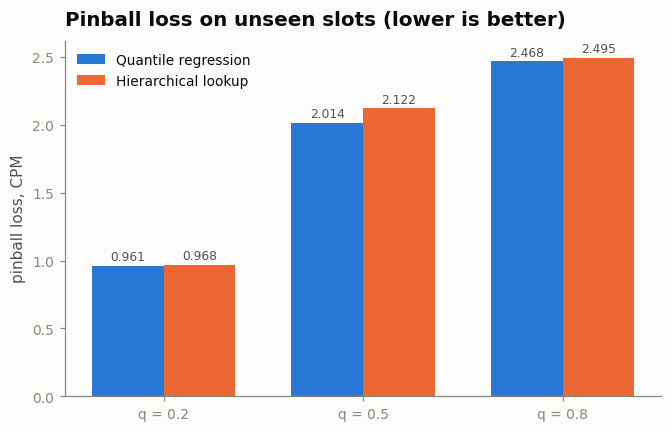

In [22]:
fig = ml.plot_qr_coverage(qr); save(fig, "ml_qr_coverage.png"); plt.show()
fig = ml.plot_qr_pinball(qr); save(fig, "ml_qr_pinball.png"); plt.show()

Coverage is the share of test clearing prices that fall below the recommended bid,
which is the win rate a bidder would actually get. Both models land within a few
points of their targets on slots they have never seen: the regressor at 0.28, 0.54
and 0.80 for targets of 0.2, 0.5 and 0.8, the lookup at 0.26, 0.52 and 0.80. Both
lean slightly high at the lower quantiles, which means bidding a little more than
needed to reach a low win rate. The lookup is marginally closer to target at 0.2 and
0.5.

Pinball loss is the proper score for a quantile forecast, and there the regressor
wins at every quantile: 0.961 against 0.968 CPM at the 20th percentile, 2.015
against 2.122 at the median, 2.468 against 2.495 at the 80th. The gap is small in
absolute CPM but it comes entirely from rows where the lookup has nothing specific
to say. Splitting the median by auction type shows the regressor is closer to target
on first-price traffic (0.55 against 0.52) and the lookup on the much smaller
second-price set (0.54 against 0.49).

What this means for a bidder: keep the lookup for slots with history, since it is
exact and needs no training, and route new pairs to the regressor instead of the
domain or global fallback. The two agree on the general price level (median
recommended bids of 1.61 and 1.31 CPM at the 50% target), so switching between them
does not produce jumps.

Caveats. This is one day of data, so there is no temporal holdout; a real deployment
would train on earlier days and test on later ones, and clearing prices drift. The
identifiers are hashed, so the models cannot generalise from the text of a url; the
encodings only work where the same hash recurs. And both experiments use the
feedback bid as the clearing price, which is a good but not exact market read on
lost first-price auctions.


---
## More layers: what else the day tells us

The three assignment questions leave a lot of the log unread. This section adds
seven layers, each chosen for what a bidder could do with it the next morning: how
much we overpay when we win, how the day breathes hour by hour, how concentrated
the supply is, which browsers and operating systems click, whether cookie age
matters, what kinds of publishers hide behind the hashed domains, and where in the
country the clicks come from.

Each chart form was picked with the Visual Vocabulary method: name the
relationship the reader should see first (distribution, change over time,
part-to-whole, magnitude, correlation, spatial), then choose the chart inside that
family. The reasoning sits next to each figure. The code is in `src/layers.py`
and `src/layer_plots.py`.

One limit first. `user_id` is unique on every row: the file holds one impression
per user. Frequency capping, reach and ad fatigue cannot be studied in this
sample, and the check below is here so nobody tries.


In [23]:
import layers as ly
import layer_plots as lp
import decode as dc

overall_ctr = float(won["conversion"].mean())
ly.user_uniqueness_report(df)

{'n_rows': 249232,
 'n_unique_users': 249232,
 'one_impression_per_user': True,
 'max_impressions_per_user': 1}

### Bid shading: paying for wins we already had

In a first-price auction the winner pays their own bid, and `feedback_bid` tells us
the runner-up. Everything between the two is money that did not change the
outcome. The relationship to show is a distribution (how is the overpay spread
across wins?), so the left panel is a histogram of overpay as a share of our bid.
The right panel replays the day with every bid cut by a flat percentage and tracks
two shares against the original: wins kept and spend saved.

,value
n_won_first_price,"38,167.000"
n_won_below_runner_up_anomalies,273.000
overpay_cpm_median,0.331
overpay_cpm_mean,0.982
overpay_ratio_median,0.412
overpay_ratio_p25,0.205
overpay_ratio_p75,0.643
share_paid_over_2x_runner_up,0.399
first_price_spend_cpm_sum,"79,259.667"
runner_up_cpm_sum,"41,782.610"


,shade,win_retained,spend_saved,cost_per_win_before,cost_per_win_after,impressions_lost
0,0%,98.1%,0.5%,2.077,2.106,718
1,5%,93.1%,9.6%,2.077,2.016,"2,637"
2,10%,88.0%,18.4%,2.077,1.924,"4,564"
3,15%,82.7%,27.1%,2.077,1.830,"6,606"
4,20%,75.5%,35.9%,2.077,1.763,"9,345"
6,30%,63.4%,51.1%,2.077,1.600,"13,951"


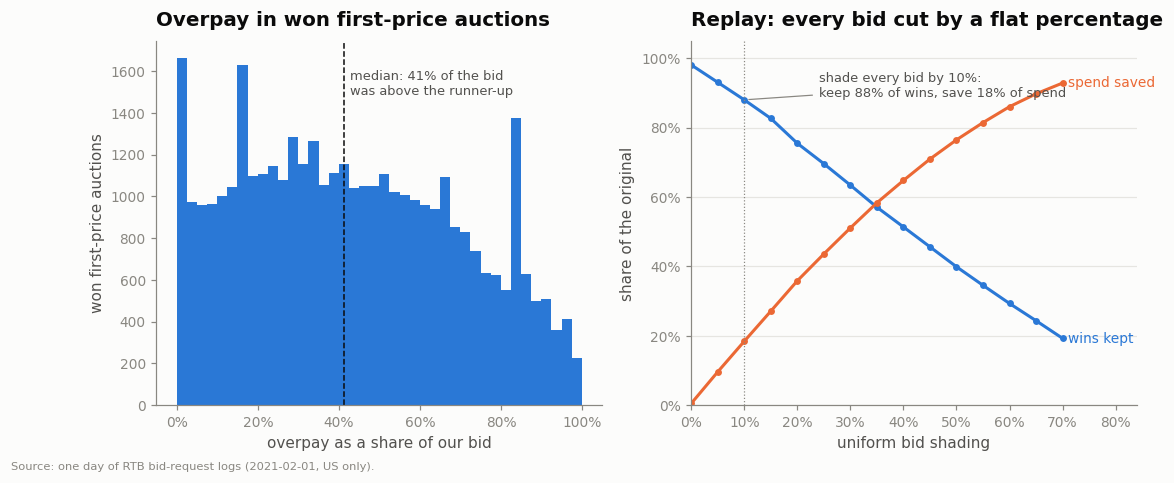

In [24]:
stats = ly.overpay_stats(bidded)
fp_won = ly.overpay_frame(bidded)
curve = ly.shading_curve(bidded)

display(pd.Series(stats, name="value").to_frame().style.format("{:,.3f}"))
display(curve.loc[curve["shade"].isin([0.0, 0.05, 0.10, 0.15, 0.20, 0.30])].style.format({
    "shade": "{:.0%}", "win_retained": "{:.1%}", "spend_saved": "{:.1%}",
    "cost_per_win_before": "{:.3f}", "cost_per_win_after": "{:.3f}", "impressions_lost": "{:,.0f}"}))
fig = lp.plot_overpay(fp_won, curve, stats); save(fig, "layer_overpay.png"); plt.show()

Half of our winning first-price bids sat more than 41% above the runner-up, and
in four wins out of ten we paid more than double what was needed. Summed over the
day, the runner-up prices come to 53% of what we paid, so the ceiling on savings is
about 47% of first-price spend. Reaching that ceiling needs the runner-up price
before the auction, which nobody has. A flat 10% shading is a policy we could
actually run: it keeps 88% of the wins, saves 18% of the spend, and cuts the cost
per won impression from 2.08 to 1.92 CPM. The losses tell the same story from the
other side. When we lose a first-price auction the winner is usually far above us
(median gap about 1 CPM) and only 4% of losses were within 10% of our bid. We are
rarely outbid by a hair; when we win, we win by too much.

A small data quirk: 273 won rows (0.7%) report a runner-up above our own bid. They
stay in the counts and are clipped to zero in the histogram.

### The day's rhythm

Five quantities move through the same 24 hours, so this is change over time, and
the form is a column of small multiples on a shared hour axis rather than one
chart with five scales. The grey band marks 08 to 10 UTC, the middle of the night
for most of the United States.

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
requests,"14,691.000","14,137.000","14,237.000","11,088.000","8,884.000","7,732.000","5,754.000","4,103.000","3,395.000","3,225.000","3,910.000","5,697.000","7,781.000","11,143.000","13,457.000","15,038.000","13,923.000","16,366.000","13,331.000","14,005.000","12,814.000","12,390.000","10,790.000","11,341.000"
bid_rate,0.535,0.558,0.553,0.535,0.514,0.469,0.427,0.426,0.386,0.398,0.382,0.437,0.450,0.437,0.446,0.458,0.480,0.490,0.522,0.504,0.538,0.543,0.550,0.539
win_rate,0.392,0.420,0.439,0.438,0.469,0.305,0.319,0.310,0.286,0.284,0.304,0.287,0.292,0.322,0.334,0.326,0.360,0.367,0.371,0.388,0.380,0.384,0.404,0.413
median_cpm,0.571,0.589,0.608,0.620,0.645,0.664,0.639,0.648,0.689,0.778,0.774,0.741,0.764,0.739,0.780,0.792,0.895,0.930,0.815,0.922,0.808,0.775,0.792,0.860
ctr,0.090,0.089,0.085,0.099,0.101,0.117,0.092,0.091,0.120,0.096,0.116,0.109,0.091,0.103,0.083,0.082,0.095,0.076,0.096,0.113,0.089,0.090,0.104,0.096
served,"3,078.000","3,317.000","3,459.000","2,596.000","2,138.000","1,107.000",783.000,541.000,374.000,365.000,455.000,714.000,"1,023.000","1,569.000","2,005.000","2,244.000","2,401.000","2,943.000","2,582.000","2,740.000","2,621.000","2,582.000","2,396.000","2,529.000"


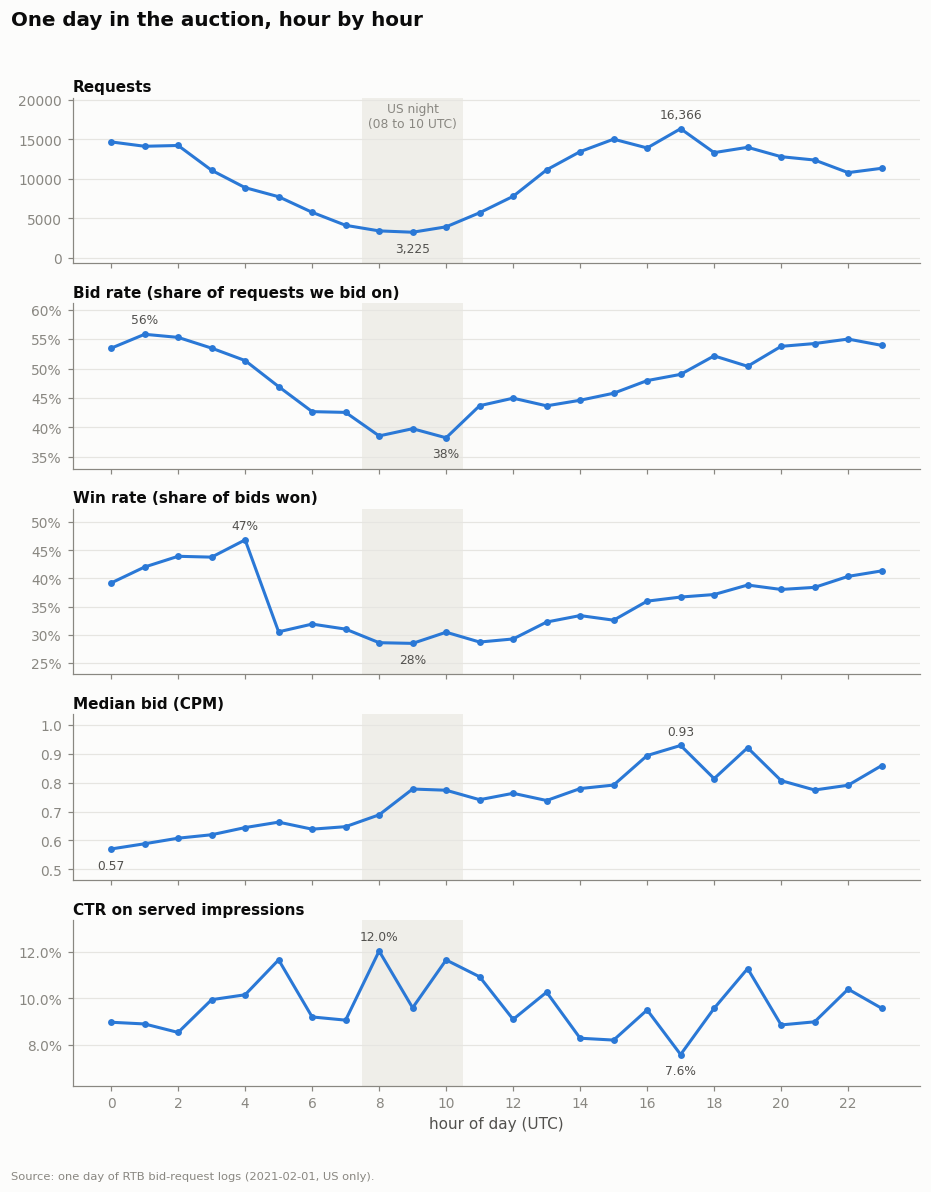

In [25]:
hp = ly.hourly_profile(df, bidded, won)
display(hp.set_index("hour").T.style.format("{:,.3f}"))
fig = lp.plot_hourly(hp); save(fig, "layer_hourly.png"); plt.show()

Requests fall from about 16,000 an hour in the US afternoon to 3,200 at 09 UTC.
Our bid rate falls with them (56% at 01 UTC, 38% at 08 UTC), which suggests the
bidder filters harder when traffic is thin rather than chasing it. Win rate peaks
at 47% at 04 UTC and bottoms at 28% in the trough, while the median bid climbs from
0.57 CPM at midnight UTC to 0.93 CPM at 17 UTC: the afternoon is both busier and
more expensive per impression. CTR by hour swings between 7.6% and 12.0%, but each
hourly point rests on a few hundred to two thousand served impressions, so read
that line as a range rather than a schedule.

### Volume is concentrated

The question is how the whole splits across publishers, so the family is
part-to-whole and the form is a Lorenz curve: domains ranked from smallest to
largest on the x axis, their cumulative share of impressions on the y axis. The
dashed diagonal is what equal shares would look like; the further a curve sags
below it, the more concentrated the supply. Gini summarises the sag in one number.

,column,n_unique,gini,top_10_share,top_50_share,top_100_share,top_500_share
0,domain,8635,0.918,23.6%,50.0%,63.6%,86.5%
1,url,44208,0.786,13.3%,26.7%,34.2%,54.5%
2,ad_slot,35255,0.814,8.5%,21.4%,29.3%,54.6%


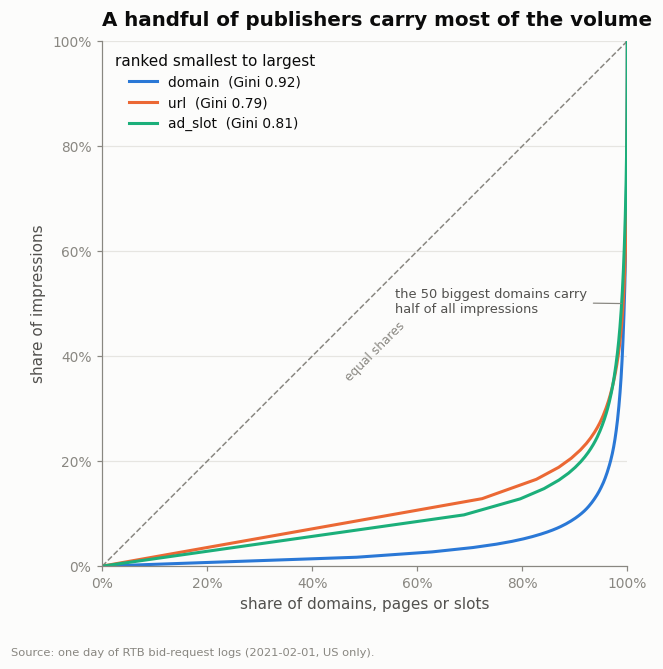

In [26]:
conc = ly.concentration_table(df)
display(conc.style.format({"gini": "{:.3f}", "top_10_share": "{:.1%}", "top_50_share": "{:.1%}",
                           "top_100_share": "{:.1%}", "top_500_share": "{:.1%}"}))
curves = {c: (ly.lorenz_points(df[c].value_counts().to_numpy()), ly.gini(df[c].value_counts().to_numpy()))
          for c in ("domain", "url", "ad_slot")}
fig = lp.plot_lorenz(curves, n_domains=int(df["domain"].nunique())); save(fig, "layer_lorenz.png"); plt.show()

The 50 largest domains (0.6% of 8,635) carry half of all impressions and the top
500 carry 87%. A Gini of 0.92 at the domain level is extreme even for web traffic.
For the bid model in question 3 this is good news: the pairs that matter most for
spend are exactly the ones with enough history to estimate a price curve, and the
long tail of one-off pages is where the pooled fallback earns its keep.

### Browsers and operating systems

The user agent string is one of the few fields left in the clear. Comparing sizes
across a handful of categories is a magnitude story, so sorted horizontal bars do
the work: share of impressions on the left, CTR on served impressions on the right,
with thin categories (under 300 served) greyed out.

,browser,n,share,served,ctr
0,Chrome,"136,591",54.8%,"25,245",9.90%
1,Safari,"36,819",14.8%,"6,379",9.89%
2,Other,"31,979",12.8%,"6,281",9.31%
3,Edge,"31,681",12.7%,"6,571",8.07%
4,Firefox,"11,784",4.7%,"2,024",5.73%
5,Opera,378,0.2%,62,11.29%


,os,n,share,served,ctr
0,Windows,"101,019",40.5%,"19,518",6.97%
1,Android,"60,432",24.2%,"10,919",14.11%
2,iOS,"51,354",20.6%,"10,542",9.74%
3,macOS,"31,685",12.7%,"5,087",8.06%
4,ChromeOS,"3,764",1.5%,332,6.93%
5,Linux,867,0.3%,147,3.40%
6,Other,111,0.0%,17,5.88%


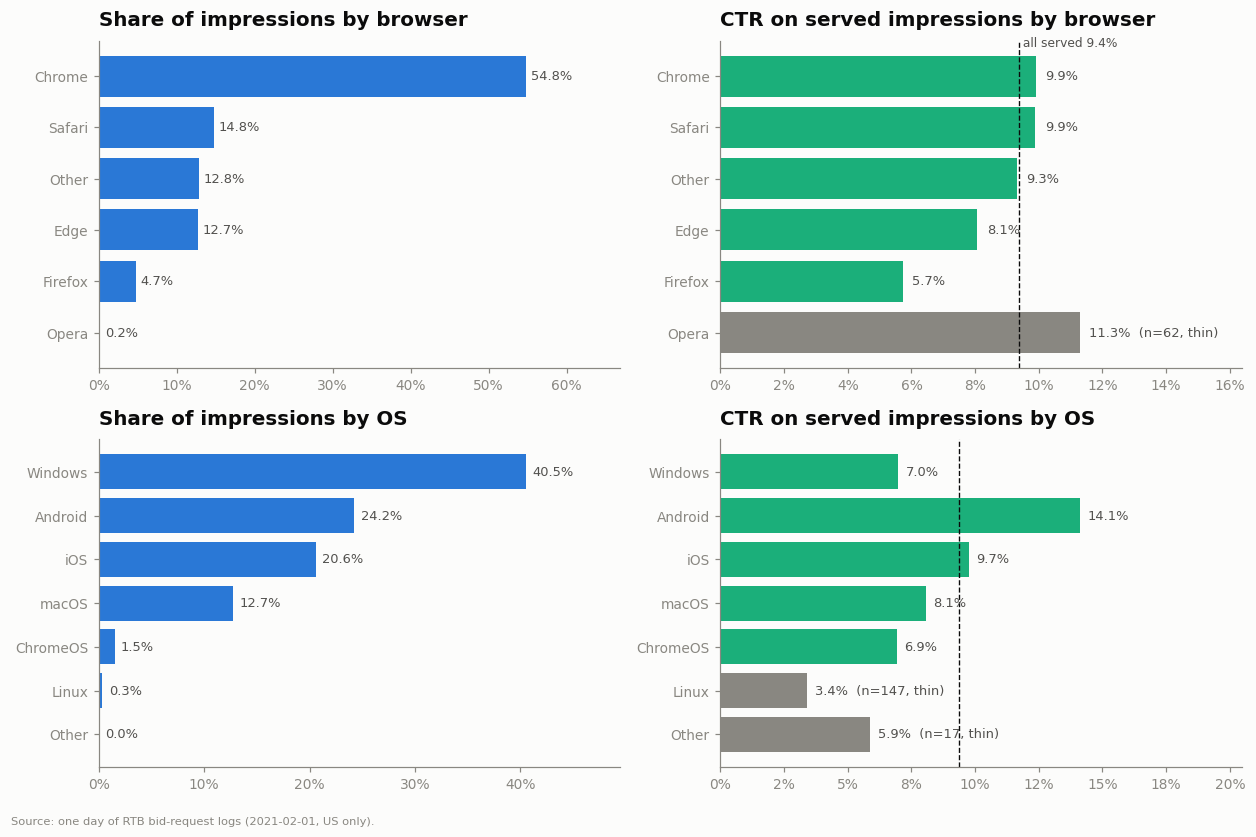

In [27]:
browser, os_table = ly.browser_os_summary(df, won)
fmt = {"share": "{:.1%}", "ctr": "{:.2%}", "n": "{:,.0f}", "served": "{:,.0f}"}
display(browser.style.format(fmt))
display(os_table.style.format(fmt))
fig = lp.plot_browser_os(browser, os_table, overall_ctr); save(fig, "layer_browser_os.png"); plt.show()

Chrome and Safari click at the same rate (9.9%), Edge trails at 8.1% and Firefox
at 5.7%. That fits the device story from question 2 more than it says anything
about browsers: Firefox and Edge are almost entirely desktop traffic. The operating
system split makes it plain. Android users click on 14.1% of served impressions,
iOS on 9.7%, Windows on 7.0%. For a CTR model, OS is a cleaner feature than
browser and largely a proxy for device type, so one of the two belongs in the
model, not both.

### Cookie age

The buckets are ordered, so this is change along an ordered axis and a line with
one point per bucket is the natural form. Support is printed under each bucket
because the buckets are very unequal in size.

,cookie_age,served,clicks,ctr
0,new (0),"23,232","2,090",9.00%
1,under 1 day,"1,613",118,7.32%
2,1 to 7 days,"1,612",129,8.00%
3,7 to 30 days,"4,524",426,9.42%
4,30 to 90 days,"3,160",307,9.72%
5,90 to 365 days,"8,720",910,10.44%
6,over 1 year,"3,701",388,10.48%


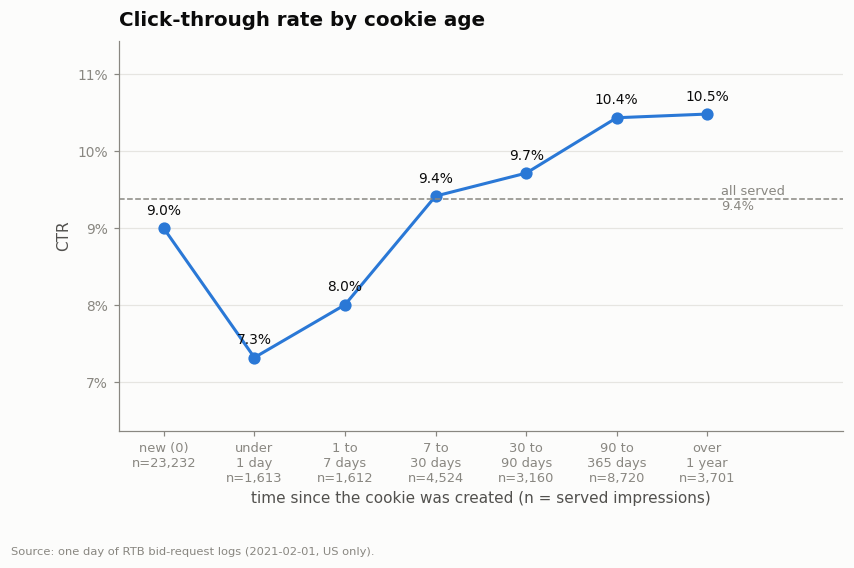

In [28]:
ck = ly.cookie_age_ctr(won)
display(ck.style.format({"served": "{:,.0f}", "clicks": "{:,.0f}", "ctr": "{:.2%}"}))
fig = lp.plot_cookie_age(ck, overall_ctr); save(fig, "layer_cookie_age.png"); plt.show()

Half of all served impressions (23,232) go to a brand-new cookie, and those users
click at 9.0%, close to average. Cookies up to a day old click least (7.3%), those
up to a week old only slightly more (8.0%), and from there the rate climbs with
age to 10.5% for cookies older than a year. One reading: a new cookie is often a
first visit (curious, willing to click), while an established cookie belongs to a
regular whose behaviour is stable. Either way the shape is monotone after the
first day, which makes a bucketed cookie age a cheap and well-behaved CTR feature.
`cookie_age_seconds` takes only 77 distinct values, so it arrives pre-bucketed.

### Publisher archetypes

The hashes hide who a publisher is, but how its traffic behaves is visible: device
mix, language, viewability, session depth, auction type, connection, price level,
how often we win, how often users click, and the hour its traffic peaks. For the
294 domains with at least 100 impressions we standardise those traits and let
KMeans group them, choosing the number of groups by silhouette. Two traits plotted
against each other is a correlation story, so the chart is a bubble scatter:
device mix on the x axis, price level on the y axis, bubble area for volume, colour
for the group.

294 domains with at least 100 impressions; k=3 chosen by silhouette


,k,silhouette
0,3,0.227
1,4,0.222
2,5,0.226
3,6,0.193


,archetype,n_domains,impressions,mobile_share,second_price_share,wifi_share,viewability_mean,session_depth_median,median_bid,win_rate,ctr
0,"mobile, more cellular",95,"108,878",89%,2%,84%,62,4.4,1.23,36%,12.9%
1,"desktop, low CTR",178,"84,462",4%,3%,99%,60,27.7,1.11,38%,6.9%
2,"second-price, premium CPM",21,"7,882",31%,96%,93%,66,3.4,24.07,88%,14.2%


desktop-only domains (under 5% mobile): 172   mobile-only (over 95%): 56
second-price impressions: 21,966 across 2,366 domains; the top 5 domains hold 25% of them


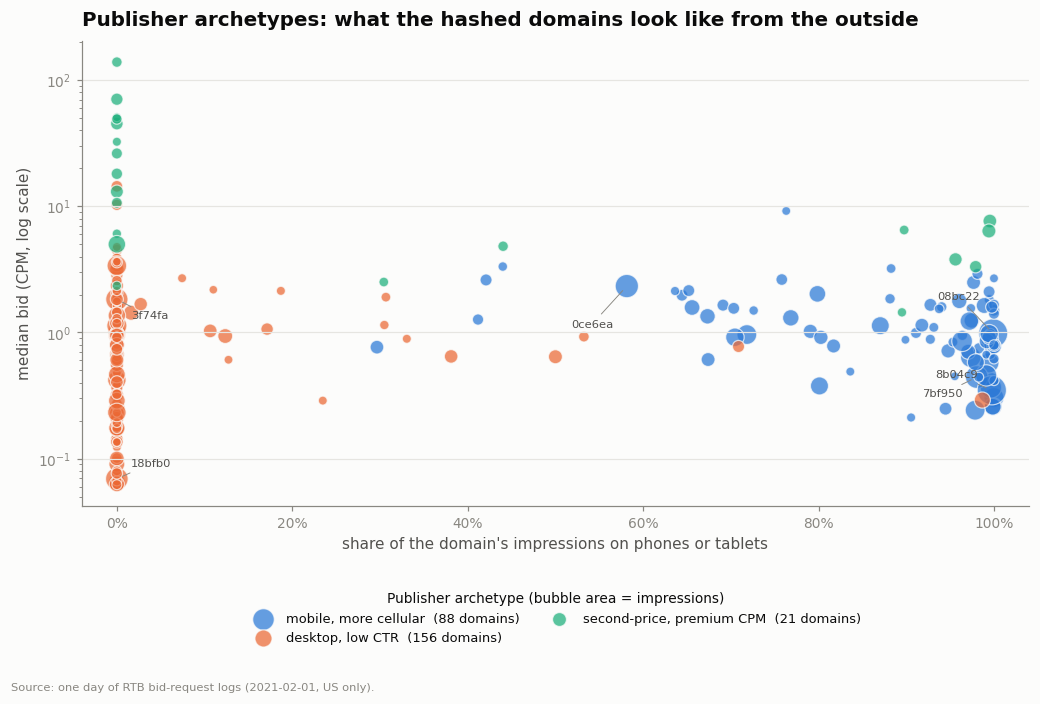

In [29]:
fp_dom = ly.domain_fingerprints(df, bidded, won, min_n=100)
arch = ly.publisher_archetypes(fp_dom)
print(f"{len(fp_dom)} domains with at least 100 impressions; k={arch['best_k']} chosen by silhouette")
display(arch["silhouette"].style.format({"silhouette": "{:.3f}"}))
cols = ["archetype", "n_domains", "impressions", "mobile_share", "second_price_share", "wifi_share",
        "viewability_mean", "session_depth_median", "median_bid", "win_rate", "ctr"]
display(arch["centroids"][cols].style.format({
    "impressions": "{:,.0f}", "mobile_share": "{:.0%}", "second_price_share": "{:.0%}", "wifi_share": "{:.0%}",
    "viewability_mean": "{:.0f}", "session_depth_median": "{:.1f}", "median_bid": "{:.2f}", "win_rate": "{:.0%}", "ctr": "{:.1%}"}))
print(f"desktop-only domains (under 5% mobile): {(fp_dom['mobile_share'] < 0.05).sum()}   "
      f"mobile-only (over 95%): {(fp_dom['mobile_share'] > 0.95).sum()}")
sp = df.loc[df["auction_type"] == "SECOND_PRICE", "domain"].value_counts()
print(f"second-price impressions: {sp.sum():,} across {len(sp):,} domains; the top 5 domains hold {sp.head(5).sum() / sp.sum():.0%} of them")
fig = lp.plot_archetypes(arch["labelled"], arch["names"]); save(fig, "layer_archetypes.png"); plt.show()

Three groups come out, and they are easy to recognise. About 180 domains are
desktop publishers: almost no mobile traffic, very deep sessions (a median near 28
impressions per session, which reads like long browsing sessions on content or
utility sites) and a low 6.9% CTR. About 95 domains are mobile publishers: 89% of
impressions on phones or tablets, short sessions, some cellular traffic and a
12.9% CTR. The third group is small (21 domains, 3% of impressions) and odd: 96%
of its auctions are second-price, the median bid is around 24 CPM, we win 88% of
the time, and its CTR is the highest of all at 14.2%. This is the premium
inventory that made `auction_type` look so strange in question 1, and it is
concentrated: five domains hold a quarter of all second-price impressions.

The clustering is soft (silhouette around 0.23), so the boundaries are fuzzy, but
for a bidder the three-way split is actionable: separate pacing and bid
strategies for desktop, mobile and the second-price premium pool, rather than one
global policy.

### Where the clicks are

Geography is a spatial story, and the fair form for state-level rates is a tile
grid map rather than a true map: every state gets the same square, so Rhode Island
is as readable as Texas and the eye is not drawn to land area, which has nothing
to do with impressions. Each tile prints the state code and its CTR; states with
fewer than 300 served impressions are hatched and left unrated, because a rate on
90 impressions is noise.

,state_code,impressions,bid_rate,bidded,win_rate,median_bid,served,clicks,ctr
0,CA,"22,710",48.3%,"10,962",32.3%,0.61,"3,536",357,10.10%
1,FL,"19,272",50.3%,"9,698",34.2%,0.75,"3,320",325,9.79%
2,TX,"18,246",50.6%,"9,226",38.0%,0.76,"3,508",357,10.18%
3,NY,"15,189",49.3%,"7,485",36.2%,0.70,"2,713",274,10.10%
4,PA,"10,932",49.4%,"5,401",38.3%,0.76,"2,068",198,9.57%
5,IL,"9,688",51.6%,"4,997",35.9%,0.68,"1,796",153,8.52%
6,OH,"9,114",50.5%,"4,604",42.0%,0.81,"1,935",189,9.77%
7,GA,"8,690",50.7%,"4,407",37.5%,0.79,"1,652",168,10.17%
8,NC,"7,880",48.5%,"3,825",37.5%,0.77,"1,435",124,8.64%
9,NJ,"7,787",49.5%,"3,857",34.0%,0.62,"1,313",112,8.53%


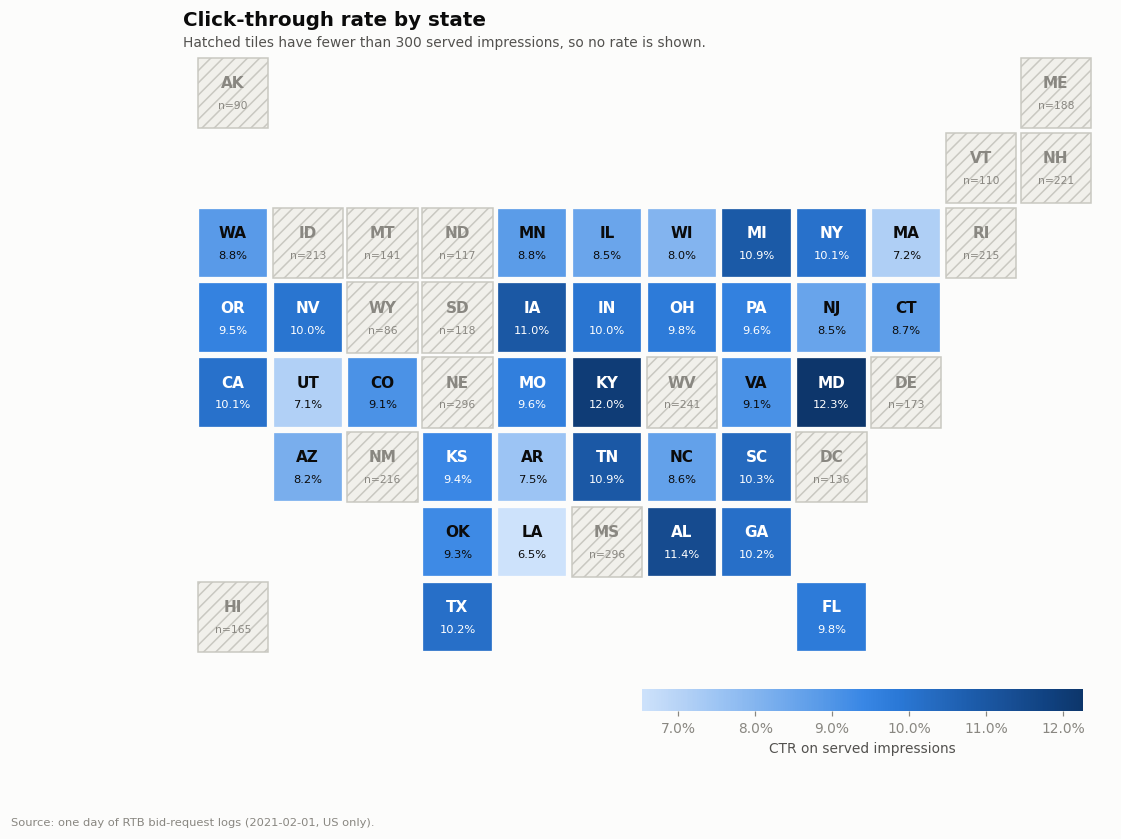

In [30]:
states = ly.state_summary(df, bidded, won)
display(states.head(15).style.format({"impressions": "{:,.0f}", "bid_rate": "{:.1%}", "bidded": "{:,.0f}", "win_rate": "{:.1%}",
                                       "median_bid": "{:.2f}", "served": "{:,.0f}", "clicks": "{:,.0f}", "ctr": "{:.2%}"}))
fig = lp.plot_state_tile_map(states); save(fig, "layer_state_map.png"); plt.show()

Among states with enough served impressions, Maryland (12.3%), Kentucky (12.0%),
Alabama (11.4%) and Iowa (11.0%) click most; Louisiana (6.5%), Utah (7.1%),
Massachusetts (7.2%) and Arkansas (7.5%) click least. The spread is wide, almost a
factor of two, but two cautions apply before treating geography as a strong
signal: state is missing on 3.4% of rows, and the mix of devices and publishers
differs by state, so part of this map is the device effect wearing a different
hat. That is consistent with the modest information value `state_code` earned in
question 2.

### What the extra layers add for a bidder

Two of them change money directly. Bid shading in first-price auctions is the
largest lever in the whole dataset: a flat 10% cut would have saved 18% of
first-price spend while keeping 88% of wins, and a per-slot shading policy built
on the question 3 price curves could approach the 47% ceiling. The hourly profile
says the afternoon is expensive and the early morning is cheap and easy to win,
which is an argument for time-of-day pacing. The rest sharpen the CTR feature set:
operating system (or device), cookie age and the publisher archetype are cheap,
stable and, in this sample, clearly separated.

---
## Can the obfuscation be undone?

Five columns are hidden. `domain`, `url`, `ad_slot` and `publisher_properties`
arrive as 32-character hex strings and `user_id` is a UUID. Before trusting the
anonymisation we should test it the way a careful adversary would, cheap attacks
first. And even when the hashes hold, the relationships between them still
describe the hidden schema. Both questions get an answer below; the code is in
`src/decode.py`.

,column,n_distinct,lengths,share_32_lower_hex,first_digit_max_share,first_digit_min_share,reads_as
0,domain,"8,635",32,100.0%,0.069,0.056,32-hex digest (MD5-shaped)
1,url,"44,208",32,100.0%,0.065,0.059,32-hex digest (MD5-shaped)
2,ad_slot,"35,255",32,100.0%,0.065,0.059,32-hex digest (MD5-shaped)
3,publisher_properties,"6,802",32,100.0%,0.067,0.059,32-hex digest (MD5-shaped)
4,user_id,"249,232",36,0.0%,nan,nan,UUID v4 (100.0% match)


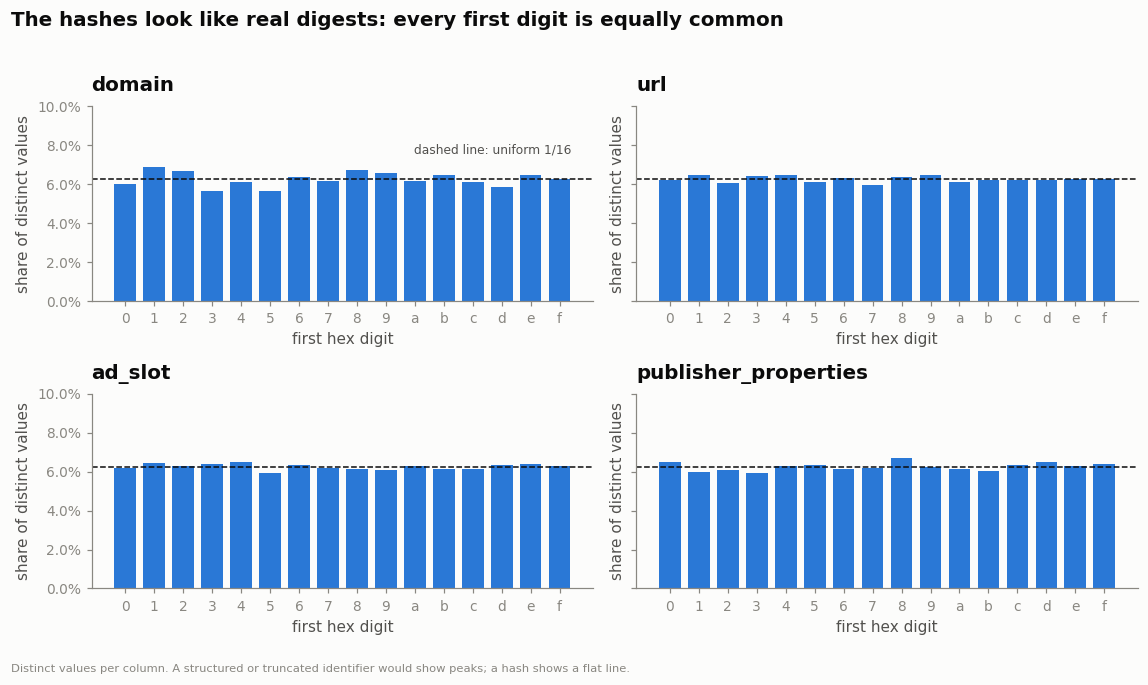

In [31]:
import decode as dc
import layer_plots as lp

fmt = dc.hash_format_report(df)
display(fmt.style.format({"share_32_lower_hex": "{:.1%}", "first_digit_max_share": "{:.3f}",
                          "first_digit_min_share": "{:.3f}", "n_distinct": "{:,.0f}"}))
nib = dc.nibble_frequencies(df)
fig = lp.plot_nibbles(nib); save(fig, "decode_nibbles.png"); plt.show()

All four fields are exactly 32 lowercase hex characters, the shape of an MD5
digest (or a truncated SHA), and the first digit of the distinct values is spread
evenly across 0 to f (between 5.6% and 6.9% each, against a uniform 6.25%). An
encoded or truncated identifier would show structure here; a digest does not.
`user_id` matches the UUID version 4 layout on every row, which means it is random
by construction and carries no information at all.

### What the structure leaks

If a hash is applied to a field one value at a time, equal inputs still give equal
outputs, so the joins between fields survive intact. The matrix below asks, for
each ordered pair, what share of the row field's values ever appear with more than
one value of the column field.

fixed,domain,url,ad_slot,publisher_properties
given,,,,
domain,1.000,0.623,0.570,0.791
url,1.000,1.000,0.798,0.934
ad_slot,0.981,0.786,1.000,0.964
publisher_properties,0.870,0.643,0.687,1.000


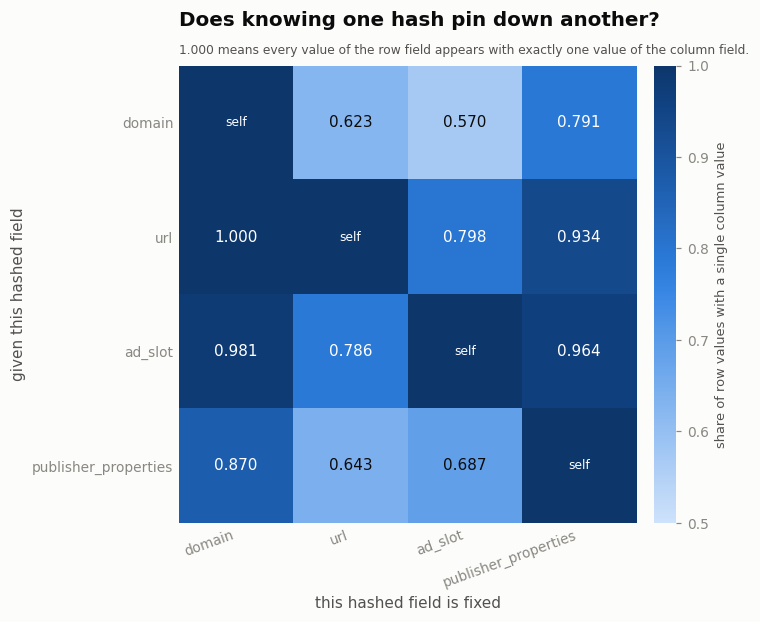

In [32]:
fd = dc.functional_dependency_matrix(df)
display(fd.style.format("{:.3f}"))
fig = lp.plot_fd_matrix(fd); save(fig, "decode_fd_matrix.png"); plt.show()

Three facts about the hidden schema fall out.

A page belongs to exactly one domain (`url` to `domain` is 1.000), so the `url`
hash is a hash of the full page and not of something that spans sites.

An ad slot is a site-level placement, not a page-level one. `ad_slot` pins down
the domain 98% of the time but the page only 79% of the time: one slot id (think
"leaderboard, top") is reused across many pages of the same site. That is why the
question 3 bid model pools by ad slot before it pools by domain.

`publisher_properties` sits above the domain. It fixes the domain only 87% of the
time, and a domain carries a single properties value only 79% of the time, so this
is a publisher-level configuration that several domains can share and that a
domain can switch during the day. It behaves like a seller or deal id rather than
a site attribute.

### Trying to reverse the hashes

Three cheap attacks cover what an attacker with a laptop would try first.
Dictionary: hash the one million most popular domains under nine common spellings
(bare, www, http, https, trailing slash, upper case) with four digest functions and
look for any match among the 8,635 domain hashes. Integers: hash the numbers 0 to
3,000,000, once and twice, because internal ids are often obfuscated that way.
Chaining: check whether one column is simply the hash of another. The dictionary
attack needs the Tranco list, which is not committed; when the file is absent the
cell says so and the ledger shows the result from the original run.

In [33]:
sets = dc.hash_sets(df)
display(dc.chained_hash_test(df))

ints = dc.integer_bruteforce(sets, n=1_000_000)
print(f"md5(str(i)) for i < {ints['n']:,}: {len(ints['hits'])} hits in {ints['seconds']:.1f}s")

live = [{"method": f"live: md5 of the integers 0 to {ints['n']:,}", "search_space": f"{ints['n']:,} digests", "hits": len(ints["hits"])}]
attack = dc.dictionary_attack(sets)
if attack["status"] == "ran":
    print(f"dictionary attack on {attack['wordlist']}: {attack['digests']:,} digests, {len(attack['hits'])} hits, {attack['seconds']:.0f}s")
    live.append({"method": f"live: {attack['n_words']:,} domains, 9 spellings, 4 digest functions",
                 "search_space": f"{attack['digests']:,} digests", "hits": len(attack["hits"])})
else:
    print("dictionary attack skipped:", attack["note"])
display(dc.attack_ledger(live))

,test,n_tried,hits
0,md5(url) found in domain,20000,0
1,md5(ad_slot) found in url,20000,0
2,md5(domain) found in publisher_properties,8635,0
3,md5(ad_slot) found in domain,20000,0
4,md5(publisher_properties) found in domain,6802,0


md5(str(i)) for i < 1,000,000: 0 hits in 0.5s


dictionary attack on /tmp/top-1m.csv: 36,000,000 digests, 0 hits, 17s


,method,search_space,hits,run
0,"Popular-domain dictionary (about 280 domains, ...","6,939 digests",0,recorded
1,"Tranco top 1,000,000 domains, 9 URL spellings,...","36,000,000 digests",0,recorded
2,"md5 of the integers 0 to 3,000,000 (internal-i...","3,000,000 digests",0,recorded
3,"double md5 of the integers 0 to 200,000","200,000 digests",0,recorded
4,"chained hashes: md5(url) in domain, md5(ad_slo...","4 x 20,000 values",0,recorded
5,"live: md5 of the integers 0 to 1,000,000","1,000,000 digests",0,this session
6,"live: 1,000,000 domains, 9 spellings, 4 digest...","36,000,000 digests",0,this session


Thirty-six million digests in the original run, and not one lands on a value in
the data. Neither does any integer or any chained hash. That is what a salted or
keyed hash looks like from the outside: the function is deterministic (the joins
survive) but the input space we can guess does not reach it. The obfuscation holds
against the cheap attacks, and there is no honest path to a domain name in this
file.

What remains is the side channel used in the archetypes section: a publisher's
behaviour (device mix, session depth, auction type, price level, peak hour) is in
the clear even when its name is not, and that is enough to tell a desktop content
site from a mobile app from a premium second-price deal. For the assignment that
is the useful conclusion. Identity is hidden and should stay hidden; structure and
behaviour are available and should be used.

---
## Summary

| Question | Answer in one line |
|---|---|
| 1 | 249K one-day US impressions; the funnel runs 50% bid, 37.5% win, 9.4% CTR on won impressions; prices are heavy-tailed; auction type splits the market; `country` and `screen_orientation` are constant. |
| 2 | Leakage-safe, data-ranked core: `device_brand`, `device_type`, `session_depth`, `viewability`, plus light geographic and auction context. The biggest future lift is historical CTR aggregates over the ID columns, and the CTR model confirms it (AUC 0.69 to 0.78). |
| 3 | Win rate is the clearing-price CDF, so bid(X) is the X-th quantile of the clearing price per slot, estimated with hierarchical shrinkage to beat sparsity. It calibrates to target within a point or two, and quantile regression covers slots with no history. |

Beyond the brief: a flat 10% bid shading in first-price auctions would have saved
18% of spend while keeping 88% of wins; supply is highly concentrated (domain Gini
0.92); publishers fall into three behavioural archetypes; and 36 million guesses
failed to reverse a single hash, so identity stays hidden while structure and
behaviour remain usable.

Reproducible: logic in `src/`, figures in `reports/figures/`, notebook regenerated by
`build_notebook.py`.
